In [2]:
import numpy as np
import matplotlib.pyplot as plt
import RF_Track as rft
from scipy.optimize import minimize, curve_fit
from CLEAR_line import *
from partrec_gaussian_optimiser_utils import partrec_gaussian_optimiser_utils
from topasToDose import getDosemap
from uniformity_fit import *
from partrec_foil_plotting import partrec_foil_plotting
from RF_track_utils import *
from flatness import *


RF-Track, version 2.5.4

Copyright (C) 2016-2025 CERN, Geneva, Switzerland. All rights reserved.

Author and contact:
 Andrea Latina <andrea.latina@cern.ch>
 BE-ABP Group
 CERN
 CH-1211 GENEVA 23
 SWITZERLAND

This software is distributed under a CERN proprietary software
license in the hope that it will be useful, but WITHOUT ANY WARRANTY;
not even for MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.

See the COPYRIGHT and LICENSE files at the top-level directory of
the RF-Track download area: https://gitlab.cern.ch/rf-track

RF-Track was compiled with GSL-2.8 and fftw-3.3.10



[RF-Track] Could not check for updates.


In [69]:
def supergaussian1D(x, A, x0, sigma_x, P):
    return A * np.exp(-( (x-x0)**2 /(2*sigma_x**2) )**P)
    
def r90(sig,P):
    return sig * np.sqrt(2) * (-np.log(0.9))**(1/(2*P))

#80% of central beam
def mask80(x):
    cdf = np.cumsum(x, dtype=float)
    cdf /= cdf[-1] # Normalize CDF to 1
    mask = (cdf >= 0.1) & (cdf <= 0.9) # Mask for central 80%
    return x[mask]

def moving_average(x):
    n = int(len(x)/10)
    """Simple moving average with window size n."""
    return np.convolve(x, np.ones(n)/n, mode='same')
            

def flatness(x):
    
    x = moving_average(x) #smoothing
    x = mask80(x)
    return (max(x)-min(x))/ (max(x)+min(x))

def plot_phsp(T,M, n_bins=50,fov=200):
     
    def scatter_hist(x, y, ax, ax_histx, ax_histy):
        
        ax_histx.tick_params(axis="x", labelbottom=True)
        ax_histy.tick_params(axis="y", labelleft=True)

        # the scatter plot:
        ax.scatter(x, y,s=1,alpha=0.5)
        ax.set_xlim(-fov,fov)
        ax.set_ylim(-fov,fov)

        ax.set_xlabel('X (mm)')  # Set x-axis label for scatter plot
        ax.set_ylabel('Y (mm)')

        slice_width = 1
        phsp_xslice = M[(M[:,2] < slice_width)]
        phsp_xslice = phsp_xslice[(phsp_xslice[:,2] > -slice_width)]
        
        phsp_yslice = M[(M[:,0] < slice_width)]
        phsp_yslice = phsp_yslice[(phsp_yslice[:,0] > -slice_width)]

        
        hist_x, bin_edges_x = np.histogram(phsp_xslice[:,0], bins=n_bins, range=[-fov, fov])
        bin_centers_x = (bin_edges_x[:-1] + bin_edges_x[1:]) / 2


        hist_y, bin_edges_y = np.histogram(phsp_yslice[:,2], bins=n_bins, range=[-fov, fov])
        bin_centers_y = (bin_edges_y[:-1] + bin_edges_y[1:]) / 2

        #fits
        p0=[np.max(hist_x),  np.mean(phsp_xslice[:,0]), np.std(phsp_xslice[:,0]), 4]
        params_x, _ = curve_fit(supergaussian1D, bin_centers_x, hist_x, p0=p0)

        params_y, _ = curve_fit(supergaussian1D, bin_centers_y, hist_y, p0=p0)
        xy_fit_curve = np.linspace(-fov, fov, 500)
       
        sig_x,sig_y, P_x, P_y = params_x[2], params_y[2], params_x[3], params_y[3]
        r90_x, r90_y = r90(sig_x, P_x), r90(sig_y, P_y)
    
        # Plot SuperGaussian fits

        ax_histx.hist(phsp_xslice[:,0], bins=n_bins, range=[-fov, fov], color="b",alpha=0.6,label= ' X-Intensity')
        ax_histx.plot(xy_fit_curve, supergaussian1D(xy_fit_curve, *params_x), 'r-', label=f"SuperGaussian Fit (P={params_x[3]:.2f},r90={r90_x:.2f})")
        ax_histx.plot(bin_centers_x, moving_average(hist_x), 'k-', label=f'Smoothed (F={flatness(hist_x):.3f})')
        ax_histx.legend()


        

        ax_histy.hist(phsp_yslice[:,2], bins=n_bins, range=[-fov, fov], color="b",alpha=0.6,label= ' Y-Intensity',orientation="horizontal")
        ax_histy.plot(supergaussian1D(xy_fit_curve, *params_y), xy_fit_curve,  'r-', label=f"SuperGaussian Fit (P={params_y[3]:.2f},r90={r90_x:.2f})")
        ax_histy.plot(moving_average(hist_y),bin_centers_y, 'k-', label=f'Smoothed (F={flatness(hist_y):.3f})')
        ax_histy.legend()

    fig, axs = plt.subplot_mosaic([['histx', '.'],
                                ['scatter', 'histy']],
                                figsize=(10, 8),
                                width_ratios=(4, 1), height_ratios=(1, 4),
                                layout='constrained')
    scatter_hist(M[:,0], M[:,2], axs['scatter'], axs['histx'], axs['histy'])
    plt.show()


from sklearn.neighbors import NearestNeighbors

def nearest_neighbor_test(x,y):
    points = np.array([x,y]).T
    nbrs = NearestNeighbors(n_neighbors=2).fit(points)
    distances, _ = nbrs.kneighbors(points)
    nn_distances = distances[:, 1]  # skip self-distance

    mean_dist = nn_distances.mean()
    std_dist = nn_distances.std()
    print(nn_distances)
    cv = std_dist / mean_dist  
    # coefficient of variation = 0.52 is poisson uniform, <0.52 is too uniform, >0.52 clustering

    return mean_dist, std_dist, cv

def mask2d(x,y):
    r = np.sqrt(x**2 + y**2)
    threshold = np.percentile(r, 60)
    mask = r <= threshold
    return x[mask],y[mask]

In [100]:

mass = RF_Track.electronmass    # particle mass in MeV/c^2
population = 10 * RF_Track.nC               # number of particles per bunch                         # particle charge in e units
P_ref = 198  
N_particles = int(100000)
charge = -1

quad_length = float(0.3)  # m
drift_length = float(0.2)

quad_currents = np.array([19.4, 20.9, 2, 30, 33, 0, 57, 61, 8, 0, 0]) # k1 values from OPTIMISE_CLEAR.py
start = 'CA.QFD0350' #'CA.ACS0270S_MECH'
end = 'CA.DHJ0840' #'CA.STLINE$END'
CLEAR_lattice = get_beamline("CLEAR_Beamline_Survey.txt",start, end, P_ref, quad_currents)
print(CLEAR_lattice.get_length())
CLEAR_lattice.append(rft.Drift(0.084))
S1 = rft.Absorber(0.0001,8.897, 13,26.982,2.7, 166)
# S1 = rft.Absorber(0.0001,'air')
S1.disable_energy_straggling()
S1.set_shape ('circular', 1,1  )
CLEAR_lattice.append(S1)
CLEAR_lattice.append(rft.Drift(0.532)) #end of s1 to s2

s2_thickness = [0.688, 0.778, 0.581, 0.386]
s2_radii = [0.4, 0.8, 1.2, 1.6]
for i in range(len(s2_thickness)):
    Slice = rft.Absorber(s2_thickness[i]/1000,31.9, 37, 288.31,1.32,-1)
    Slice.disable_energy_straggling()
    Slice.set_shape ('circular',  abs(s2_radii[i])/1000,abs(s2_radii[i])/1000 )
    # Slice.set_shape ('circular', 2,2 )
    CLEAR_lattice.append(Slice)

CLEAR_lattice.append(rft.Drift(2.024))  #drift to water tank   


15.267999999999999


In [101]:


# x,xp,y,yp = rft.qrandn(N_particles, 4).T
# momentum = np.ones(N_particles)*P_ref # 200 MeV ± 0.5%
# T = np.zeros(N_particles)
# matrix = np.column_stack((x, xp, y, yp, T, momentum)) #transpose to match Bunch6d format
# B0 = rft.Bunch6d(mass, 0.0, charge, matrix)

Twiss = RF_Track.Bunch6d_twiss()

Twiss.beta_x = 43.1        # m
Twiss.beta_y = 117      # m
Twiss.alpha_x = -0.557 
Twiss.alpha_y = 0.553
Twiss.emitt_x = 3.6     # mm.mrad normalised emittance
Twiss.emitt_y = 4.48     # mm.mrad
# Twiss.sigma_t = 10 * RF_Track.ps       # mm/c   or 37 * RF_Track.ps
# Twiss.sigma_pt = 10     # permille
Twiss.mean_xp = 0.0
Twiss.mean_yp = 0.0

B0 = RF_Track.Bunch6d_QR(mass, population, charge, P_ref, Twiss, N_particles)             # reference bunch



In [106]:
# last3_k1s = [ 534.75241575, -534.75241575,   20.    ]
Q = CLEAR_lattice.get_quadrupoles()
# # print(len(Q))
# for i in range(len(Q)-3, len(Q)):
#     Q[i].set_strength(last3_k1s[i-6])


for i in Q:
    print(i.get_strength())
    # print(i.get_gradient())



75.2340573909669
-81.04868510596027
7.758795329215808
116.31659004595663
-127.94054827753351
0.0
220.88180907038944
-236.3633072168946
31.03144760873291


In [108]:

B1 = CLEAR_lattice.track(B0)
T = CLEAR_lattice.get_transport_table(
'%S %beta_x %beta_y %alpha_x %alpha_y %sigma_x %sigma_y %sigma_px %sigma_py')
M = B1.get_phase_space('%x %xp %y %yp %E %z')

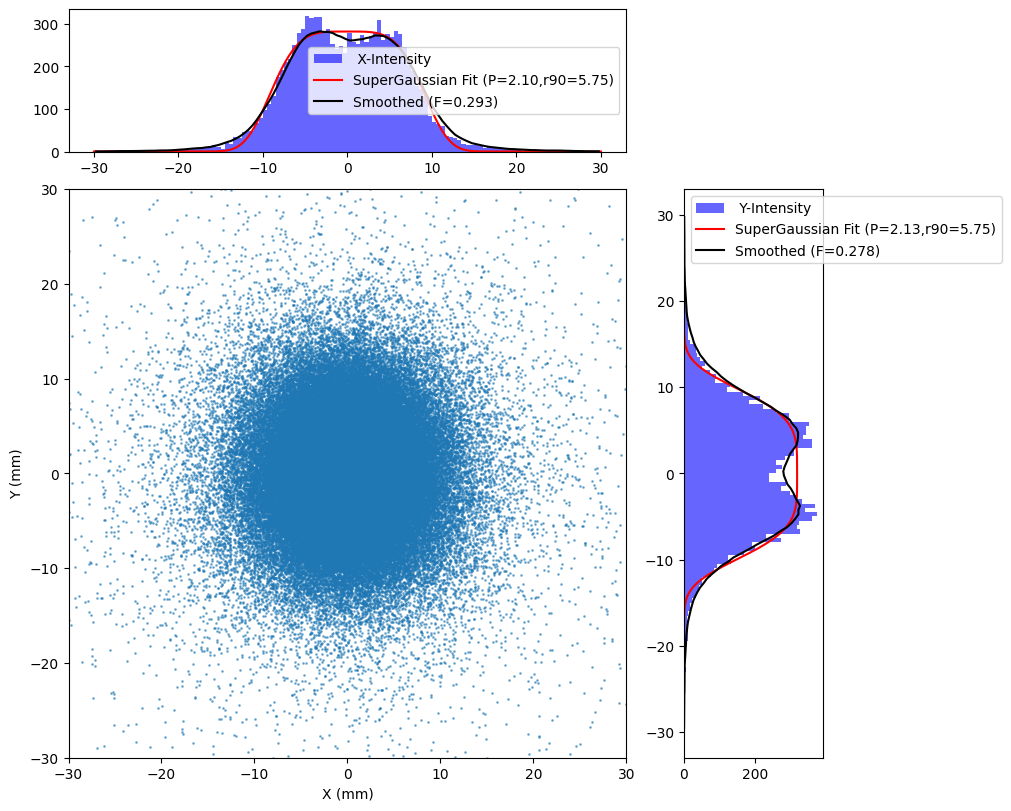

In [109]:
plot_phsp(T,M,120,30)

In [94]:
def loss (last3_k1s, lattice, B0):
    Q = lattice.get_quadrupoles()
    for i in range(len(Q)-3, len(Q)):
        Q[i].set_strength(last3_k1s[i-6])

    B1 = lattice.track(B0)
    I = B1.get_info()
    sx, sy, ax, ay= I.sigma_x, I.sigma_y, I.alpha_x, I.alpha_y
    # T = lattice.get_transport_table(
    # '%S %beta_x %beta_y %alpha_x %alpha_y %sigma_x %sigma_y %sigma_px %sigma_py')
    M = B1.get_phase_space('%x %xp %y %yp %E %z')
    # x,y = M[:,0], M[:,2]
    

    # loss = nearest_neighbor_test(x,y)[2]
    # loss = fatness(hist_x) + flatness(hist_y)
    loss = merit_beam_Uniform(B1, 5, 20, transmission=0.998)
    # loss = sx**2 + sy**2 + (sx-sy)**2 + (ax-ay)**2 
    masked_x, masked_y = mask2d(M[:,0],M[:,2])
    # loss = nearest_neighbor_test(masked_x,masked_y)[2]
    
    print('loss:', loss,'k1s =', last3_k1s)
    return loss

In [107]:
B0_opt = RF_Track.Bunch6d_QR(mass, population, charge, P_ref, Twiss, 10000)     
x0 = [20,-20,20]
res = minimize(loss,
                      x0=x0, args=(CLEAR_lattice,B0_opt),
                      bounds=[ (0,700),(-700,0),(0,700)], #highest can be 772 apparently
                      method='Powell',
                    #   tol=1e-2
                      )

print(f'Trial: M={res.fun:.2f}, k1s, ={res.x}')

loss: 23305.782414524077 k1s = [ 20. -20.  20.]
loss: 8534.987003835891 k1s = [267.37620788 -20.          20.        ]
loss: 4127.248653588818 k1s = [432.62379212 -20.          20.        ]
loss: 4235.666100305694 k1s = [534.75241575 -20.          20.        ]
loss: 5812.750806981401 k1s = [478.57111566 -20.          20.        ]
loss: 6193.213200262558 k1s = [369.5048315 -20.         20.       ]
loss: 14984.788344637425 k1s = [408.5144945 -20.         20.       ]
loss: 4198.072485814787 k1s = [450.17410802 -20.          20.        ]
loss: 13041.966744949954 k1s = [423.41485988 -20.          20.        ]
loss: 14248.201109439404 k1s = [439.32741629 -20.          20.        ]
loss: 9252.51247954384 k1s = [429.10629301 -20.          20.        ]
loss: 21010.98914062647 k1s = [435.18434871 -20.          20.        ]
loss: 10336.93219969859 k1s = [431.28022702 -20.          20.        ]
loss: 17542.88437117334 k1s = [433.60183771 -20.          20.        ]
loss: 7477.455745981114 k1s = [43

checking results